# Machine Learning - Classificação com Regressão Logística
# Previsão de Doença Cardíaca (Insuficiência Cardíaca)

**Disciplina:** Tópicos Especiais em TI

**Técnica:** Aprendizado Supervisionado - Classificação (Regressão Logística)

**Dataset real (Kaggle):** Heart Failure Prediction Dataset
Fonte: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction

### Informações do conjunto de dados
- Age: idade do paciente [anos]
- Sex: sexo do paciente [M: Masculino, F: Feminino]
- ChestPainType: tipo de dor torácica [TA, ATA, NAP, ASY]
- RestingBP: pressão arterial em repouso [mm Hg]
- Cholesterol: colesterol sérico [mm/dl]
- FastingBS: glicemia em jejum [1: > 120 mg/dl, 0: caso contrário]
- RestingECG: resultado do eletrocardiograma em repouso [Normal, ST, LVH]
- MaxHR: frequência cardíaca máxima atingida
- ExerciseAngina: angina induzida por exercício [Y, N]
- Oldpeak: depressão do segmento ST induzida por exercício
- ST_Slope: inclinação do segmento ST no pico do exercício [Up, Flat, Down]
- HeartDisease: variável alvo [1: doença cardíaca, 0: normal]

### Objetivo
Construir um classificador de **Regressão Logística**, com saída de probabilidade, capaz de
prever se um paciente tem doença cardíaca a partir de dados clínicos, avaliando o modelo com
matriz de confusão e curva ROC.

In [1]:
# Importando os pacotes que serão utilizados
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                              roc_curve, roc_auc_score)

sns.set_style('whitegrid')

## 1. Carga e Exploração dos Dados

In [2]:
df = pd.read_csv('heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
df.shape

(918, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [5]:
df.isnull().sum().sum()

np.int64(0)

## 2. Análise Exploratória

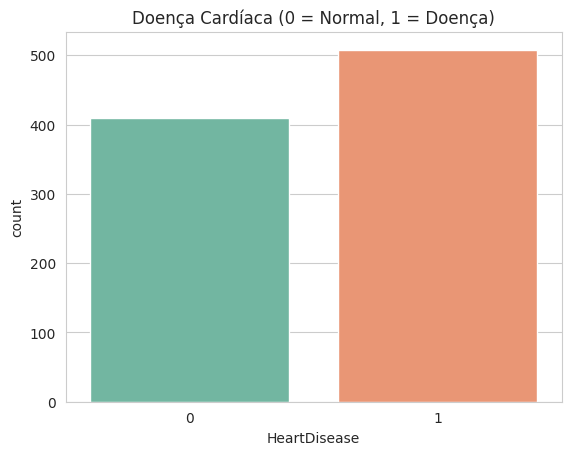

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [6]:
# Balanceamento das classes
sns.countplot(x='HeartDisease', data=df, palette='Set2')
plt.title('Doença Cardíaca (0 = Normal, 1 = Doença)')
plt.show()
df['HeartDisease'].value_counts()

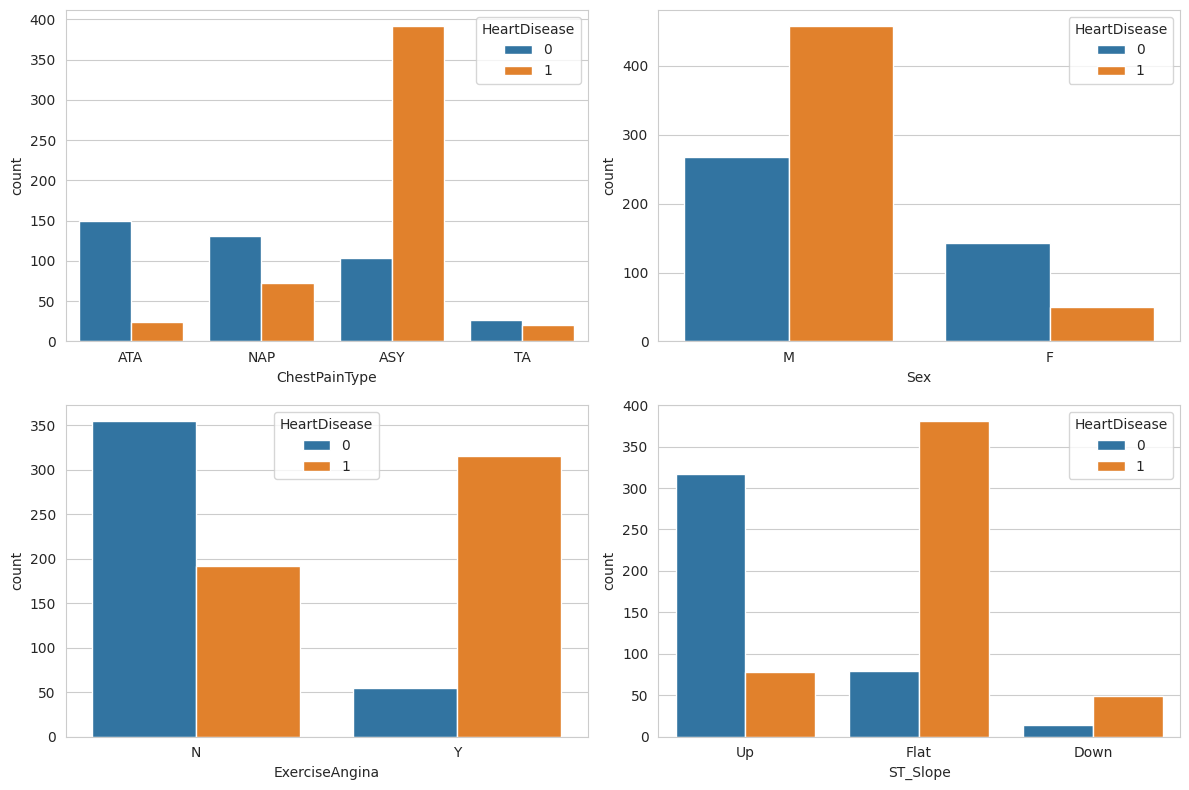

In [7]:
# Variáveis categóricas x diagnóstico
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.countplot(data=df, x='ChestPainType', hue='HeartDisease', ax=axes[0,0])
sns.countplot(data=df, x='Sex', hue='HeartDisease', ax=axes[0,1])
sns.countplot(data=df, x='ExerciseAngina', hue='HeartDisease', ax=axes[1,0])
sns.countplot(data=df, x='ST_Slope', hue='HeartDisease', ax=axes[1,1])
plt.tight_layout()
plt.show()

In [8]:
# Codificando as variáveis categóricas para variáveis numéricas
df_encoded = df.copy()
colunas_categoricas = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
encoders = {}
for col in colunas_categoricas:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    encoders[col] = le

df_encoded.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0


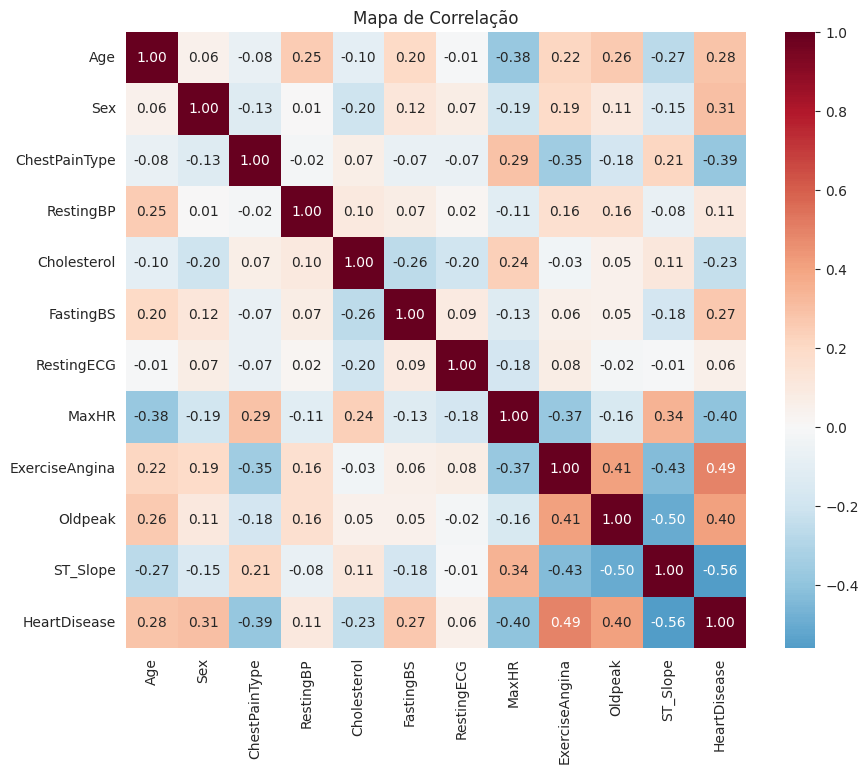

In [9]:
# Correlação das variáveis com o diagnóstico
plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Mapa de Correlação')
plt.show()

## 3. Preparação dos Dados

In [10]:
X = df_encoded.drop(columns=['HeartDisease'])
y = df_encoded['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

# Padronização das variáveis (importante para a Regressão Logística)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train.shape, X_test.shape

((688, 11), (230, 11))

## 4. Treinando o Modelo de Regressão Logística

In [11]:
modelo = LogisticRegression(max_iter=5000)
modelo.fit(X_train_scaled, y_train)

y_pred = modelo.predict(X_test_scaled)
print('Acurácia:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['Normal', 'Doença Cardíaca']))

Acurácia: 0.8521739130434782
                 precision    recall  f1-score   support

         Normal       0.85      0.82      0.83       103
Doença Cardíaca       0.85      0.88      0.87       127

       accuracy                           0.85       230
      macro avg       0.85      0.85      0.85       230
   weighted avg       0.85      0.85      0.85       230



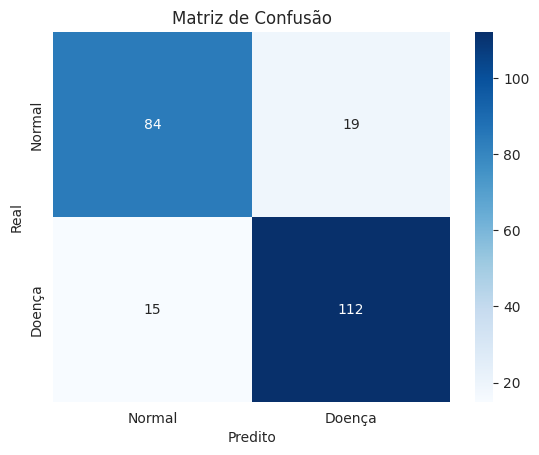

In [12]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Doença'], yticklabels=['Normal', 'Doença'])
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

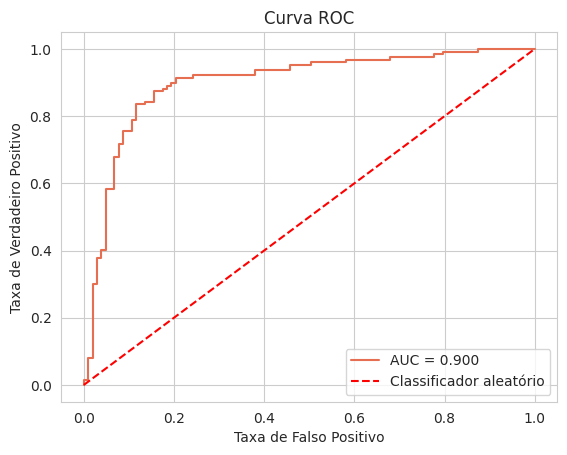

In [13]:
# Curva ROC
y_prob = modelo.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}', color='#e76f51')
plt.plot([0, 1], [0, 1], 'r--', label='Classificador aleatório')
plt.xlabel('Taxa de Falso Positivo')
plt.ylabel('Taxa de Verdadeiro Positivo')
plt.title('Curva ROC')
plt.legend()
plt.show()

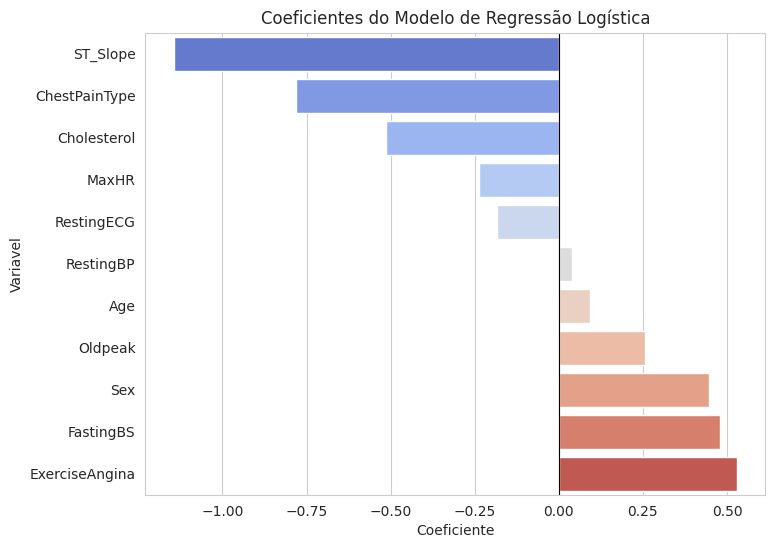

In [14]:
# Coeficientes do modelo (quais variáveis mais pesam na previsão)
coef_df = pd.DataFrame({'Variavel': X.columns, 'Coeficiente': modelo.coef_[0]}).sort_values('Coeficiente')

plt.figure(figsize=(8, 6))
sns.barplot(x='Coeficiente', y='Variavel', data=coef_df, palette='coolwarm')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coeficientes do Modelo de Regressão Logística')
plt.show()

## 5. Classificando um Novo Paciente, com Probabilidade

In [15]:
# Exemplo de novo exame, usando o primeiro paciente do conjunto de teste
exemplo = X_test.iloc[[0]]
exemplo_scaled = scaler.transform(exemplo)

res = modelo.predict(exemplo_scaled)
prob = modelo.predict_proba(exemplo_scaled)

diagnostico = 'Doença Cardíaca' if res[0] == 1 else 'Normal'
print(f'Diagnóstico previsto: {diagnostico}')
print(f'Probabilidade [Normal, Doença Cardíaca]: {prob[0].round(3)}')
print(f'Diagnóstico real: {"Doença Cardíaca" if y_test.iloc[0] == 1 else "Normal"}')

Diagnóstico previsto: Doença Cardíaca
Probabilidade [Normal, Doença Cardíaca]: [0.165 0.835]
Diagnóstico real: Doença Cardíaca


## 6. Conclusão

O modelo de Regressão Logística obteve boa acurácia e uma curva ROC com AUC alto, mostrando
boa capacidade de separar pacientes com e sem doença cardíaca. As variáveis **ST_Slope**,
**ChestPainType** e **ExerciseAngina** apareceram entre as mais influentes na previsão, o que é
consistente com a literatura médica sobre fatores de risco cardíaco.